### **Importing Libraries**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import mne
from mne.channels import read_layout
from mne.io import concatenate_raws, read_raw_edf
from mne.datasets import eegbci
from mne.decoding import CSP

# Set log-level to reduce verbosity
mne.set_log_level("WARNING")

### **Loading Sample Data**

In [2]:
# Parameters
subject = 1
runs = [6, 10, 14]

raw_fnames = eegbci.load_data(subject, runs)
raw_files = [read_raw_edf(f, preload=True) for f in raw_fnames]
raw = concatenate_raws(raw_files)

c:\Users\lacom\.conda\envs\xtra\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


In [3]:
print(raw.ch_names)


['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


In [4]:
# Set channel locations to plot topographies
from mne.channels import make_standard_montage

raw.rename_channels(lambda x: x.strip('.'))
montage = make_standard_montage('standard_1005')
raw.set_montage(montage, False);

# Band-Pass Filter
raw.filter(7.0, 30.0, method='fir')


<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>

### **Extracting Events and Creating Epochs**

C:\Users\lacom\AppData\Local\Temp\ipykernel_4612\3509501185.py:4: RuntimeWarning: event 1 missing from event_id will be ignored
  fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'], event_id=event_id);


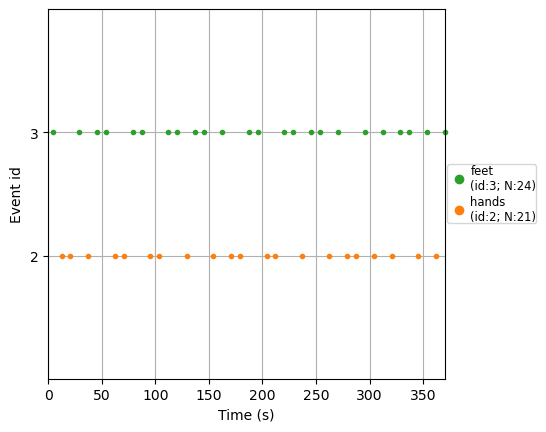

In [5]:
events, _ = mne.events_from_annotations(raw)
event_id = dict(hands=2, feet=3)

fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'], event_id=event_id);

In [6]:
# Epochs parameters
tmin, tmax = -1., 4.
baseline = None

picks = mne.pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False, exclude='bads')

epochs = mne.Epochs(raw, events, event_id, tmin, tmax, proj=True, picks=picks,
                    baseline=baseline, preload=True)


epochs.drop_bad()


In [7]:
epochs_train = epochs.copy().crop(tmin=1., tmax=2.)
labels = epochs.events[:, -1] - 2

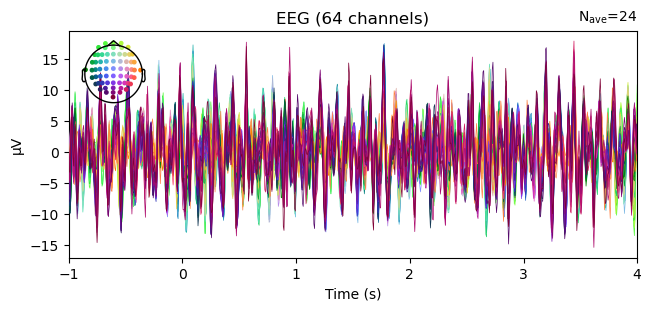

In [8]:
epochs['feet'].average().plot();

### Machine Learning

In [9]:
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from mne.decoding import SlidingEstimator, cross_val_multiscore
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score

In [10]:
event_id

{'hands': 2, 'feet': 3}

In [11]:
#To keep chance level at 50% accuracy, we first equalize the number of epochs in each condition.
epochs.equalize_event_counts(event_id)

# Separate auditory and visual epochs
hands_epochs = epochs['hands']
feet_epochs = epochs['feet']

# Print information about the equalized epochs
print(hands_epochs)
print(feet_epochs)

<Epochs | 21 events (all good), -1 – 4 s (baseline off), ~8.3 MiB, data loaded,
 'hands': 21>
<Epochs | 21 events (all good), -1 – 4 s (baseline off), ~8.3 MiB, data loaded,
 'feet': 21>


In [12]:
# Function to prepare features (flatten the epochs)
def prepare_features(epochs, event_id):
    """
    Prepare features by flattening the epochs data and assigning meaningful feature names.

    Parameters:
        epochs: mne.Epochs object
            The preprocessed epochs data.
        event_id: dict
            A dictionary mapping event names to integer event codes.

    Returns:
        X_df: pandas.DataFrame
            DataFrame with flattened features and labels.
        X_flattened: np.ndarray
            Numpy array of flattened features.
        y: np.ndarray
            Labels corresponding to each epoch.
    """
    # Get data (shape: [n_epochs, n_channels, n_timepoints])
    X = epochs.get_data()  # Shape: (n_epochs, n_channels, n_timepoints)

    # Extract channel names from raw data
    ch_names = raw.ch_names  # List of channel names
    n_channels = X.shape[1]
    n_timepoints = X.shape[2]

    # Create feature names using channel names and time points
    feature_names = []
    for ch_idx in range(n_channels):
        for t_idx in range(n_timepoints):
            feature_names.append(f"{ch_names[ch_idx]}_Time_{t_idx}")

    # Flatten the data (preserving the channel-timepoint structure)
    X_flattened = X.reshape(X.shape[0], -1)  # Shape: (n_epochs, n_channels * n_timepoints)

    # Prepare labels based on event_id
    y = np.empty(len(epochs.events), dtype=int)
    idx_hand = epochs.events[:, 2] == event_id['hands']
    idx_feet = epochs.events[:, 2] == event_id['feet']

    # Assign binary labels (0 = feet, 1 = hands)
    y[idx_hand] = 1
    y[idx_feet] = 0

    # Create a DataFrame with flattened data and meaningful feature names
    X_df = pd.DataFrame(X_flattened, columns=feature_names)

    # Add the labels to the DataFrame
    X_df['label'] = y

    return X_df, X_flattened, y


In [13]:
# Prepare the features and labels
X_df, X_flattened, y = prepare_features(epochs, event_id)

In [14]:
X_df.head()

,Fc5_Time_0,Fc5_Time_1,Fc5_Time_2,Fc5_Time_3,Fc5_Time_4,Fc5_Time_5,Fc5_Time_6,Fc5_Time_7,Fc5_Time_8,Fc5_Time_9,...,Iz_Time_792,Iz_Time_793,Iz_Time_794,Iz_Time_795,Iz_Time_796,Iz_Time_797,Iz_Time_798,Iz_Time_799,Iz_Time_800,label
0,0.000025,1.193643e-05,0.000003,0.000009,0.000018,0.000014,-0.000004,-0.000018,-0.000015,3.624795e-07,...,-0.000024,-0.000017,-0.000013,-0.000013,-0.000007,0.000010,0.000031,0.000039,0.000030,0
1,-0.000005,-8.770139e-07,0.000008,0.000017,0.000021,0.000014,0.000002,-0.000011,-0.000019,-2.260359e-05,...,0.000016,0.000009,-0.000007,-0.000013,-0.000004,0.000016,0.000042,0.000069,0.000082,1
2,-0.000012,-8.565708e-06,0.000004,0.000016,0.000019,0.000014,0.000010,0.000008,0.000002,-6.316523e-06,...,0.000040,0.000033,0.000017,-0.000003,-0.000017,-0.000017,-0.000004,0.000012,0.000016,1
3,0.000005,-4.616275e-06,-0.000012,-0.000015,-0.000012,-0.000010,-0.000014,-0.000024,-0.000031,-2.724479e-05,...,0.000037,0.000013,-0.000016,-0.000027,-0.000015,0.000003,0.000008,-0.000001,-0.000011,0
4,-0.000006,-1.843479e-05,-0.000025,-0.000021,-0.000006,0.000016,0.000034,0.000039,0.000031,1.918891e-05,...,0.000041,0.000020,-0.000018,-0.000051,-0.000056,-0.000028,0.000015,0.000042,0.000038,1


### **Split the data**


In [15]:
# Separate features and labels
X = X_df.drop(columns='label')  # Features (drop the label column)
y = X_df['label']  # Labels

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### **XGBoost + Common Spatial Pattern (CSP)**

c:\Users\lacom\.conda\envs\xtra\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:28:25] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Test Accuracy: 0.8889


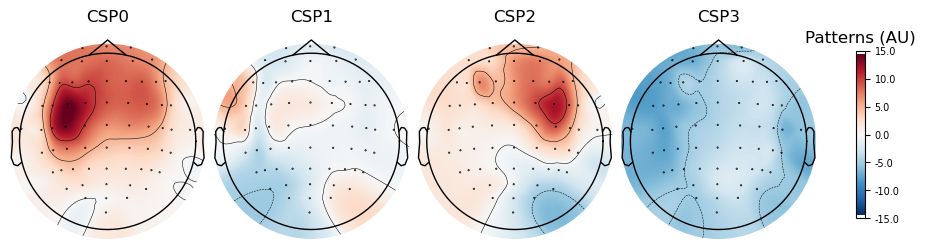

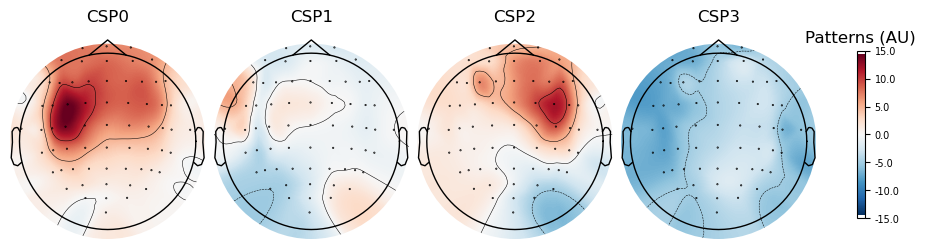

In [16]:

from sklearn.pipeline import Pipeline
from mne.decoding import CSP


# Reshape data to match CSP's expected input: (n_samples, n_channels, n_times)
n_channels = 64  # Update based on your dataset
n_times = X_train.shape[1] // n_channels  # Compute the number of time points
X_train = X_train.values.reshape(-1, n_channels, n_times)
X_test = X_test.values.reshape(-1, n_channels, n_times)

# Define CSP and XGBoost
csp = CSP(n_components=4, reg=None, log=True)
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric="logloss"
)

# Train CSP and XGBoost pipeline
pipeline = Pipeline([('CSP', csp), ('XGB', xgb)])
pipeline.fit(X_train, y_train)

# Evaluate on test data
y_pred = pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# ---- CSP Patterns Visualization ----
# Fit CSP on the entire training data for visualization purposes
csp.fit_transform(X_train, y_train)
csp.plot_patterns(epochs.info, ch_type='eeg', units='Patterns (AU)', size=1.5)

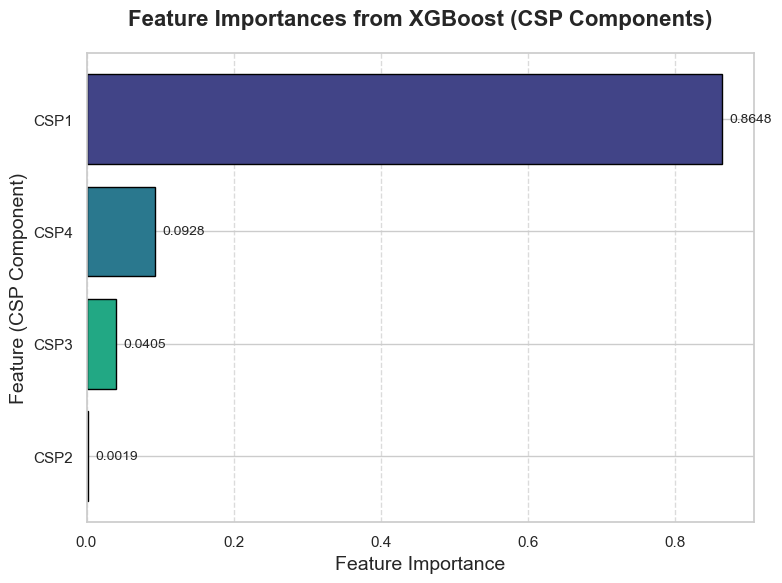

  feature  importance
0    CSP1    0.864764
3    CSP4    0.092841
2    CSP3    0.040532
1    CSP2    0.001863


In [24]:
import seaborn as sns

# Step 10: Get feature importances from the trained XGBoost model
importances = xgb.feature_importances_

# Generate synthetic feature names for CSP components
n_components = csp.n_components
feature_names = [f'CSP{i+1}' for i in range(n_components)]

# Create a DataFrame of feature importances
feature_importances_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort the DataFrame by importance
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False)

# Step 11: Visualize the top features
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

# Create a horizontal bar plot with a color gradient
bar_colors = sns.color_palette("viridis", len(feature_importances_df))
bars = plt.barh(
    feature_importances_df['feature'], 
    feature_importances_df['importance'], 
    color=bar_colors, 
    edgecolor='black'
)

# Add importance values as labels on the bars
for bar, value in zip(bars, feature_importances_df['importance']):
    plt.text(
        bar.get_width() + 0.01, 
        bar.get_y() + bar.get_height() / 2, 
        f"{value:.4f}", 
        va='center', 
        fontsize=10
    )

# Add labels, title, and invert y-axis for better readability
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Feature (CSP Component)', fontsize=14)
plt.title('Feature Importances from XGBoost (CSP Components)', fontsize=16, weight='bold', pad=20)
plt.gca().invert_yaxis()  # Display most important feature at the top

# Make gridlines subtler
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

# Step 12: Optionally, output the feature importances for further analysis
print(feature_importances_df)


In [27]:
# ---- Identify Most Important Electrodes ----
# Access spatial patterns from CSP
spatial_patterns = csp.patterns_  # Shape: (n_channels, n_components)

# Example: Most important electrodes for the 1st CSP component
csp_component = 0  # Choose CSP component (0-based index)
electrode_importances = np.abs(spatial_patterns[:, csp_component])  # Importance per electrode

# Map indices to electrode names
electrode_names = epochs.info['ch_names']  # Replace with your electrode labels
important_electrodes = pd.DataFrame({
    'Electrode': electrode_names,
    'Importance': electrode_importances
}).sort_values(by='Importance', ascending=False)

print("Most important electrodes for CSP component 1:")
important_electrodes.head(10)  # Top 10 electrodes

Most important electrodes for CSP component 1:


,Electrode,Importance
0,Fc5,0.000010
11,C2,0.000008
3,Fcz,0.000007
4,Fc2,0.000007
59,Po8,0.000007
50,Pz,0.000007
39,Ft8,0.000006
46,P7,0.000006
43,T10,0.000006
25,Af3,0.000005
